## 🏢 **California Housing Price Prediction** (Advanced Portfolio Project)

Is project mein hum California ke housing data ka use karke gharon ki keemat (Median House Value) predict karna seekh rahe hain. Yeh ek **Regression Problem** hai.

### 📥 **Step 1: Libraries Import Aur Data Load Karna**
Sabse pehle hum Data Science ki zaroori libraries **(`pandas`, `numpy`, `matplotlib`, `seaborn`)** ko import kar rahe hain aur internet se direct data load kar rahe hain taaki hum uspar kaam kar sakein.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Display the first 5 rows of the dataframe
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


### 🔍 **Step 2: Data Ka X-Ray (Data Inspection)**
Ab hum yeh check kar rahe hain ki hamare data mein kitne columns hain, unka type kya hai (Numbers hain ya Text), aur sabse zaroori baat—kya data mein koi missing value (khali jagah) hai ya nahi? Isse hume data ki health ka pata chalta hai.

In [ ]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


> 📝 **Observation:** Data mein ek bhi missing value (null value) nahi hai, iska matlab hamara data pehle se hi ekdam saaf (clean) hai.

In [ ]:
# Check for missing values in each column
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


### 📊 **Step 3: Data Ka Hisab-Kitab (Statistical Summary)**
Yahan hum data ka maths check kar rahe hain. Jaise ki California mein gharon ki average **(mean)** keemat kya hai, sabse sasta ghar kitne ka hai, aur sabse mehenga ghar kitne ka hai. Yeh hume data ki range samajhne mein madad karta hai.

In [ ]:
# Statistical summary of numeric features
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### 📉 **Step 4: Data Visualisation (Graphs Aur Charts)**
Numbers se zyada tasveerein bolti hain! Is step mein hum plots aur graphs bana kar dekh rahe hain ki columns ka aapas mein kya rishta **(correlation)** hai. Jaise logon ki kamai **(income)** badhne se ghar ki keemat par kya asar padta hai.

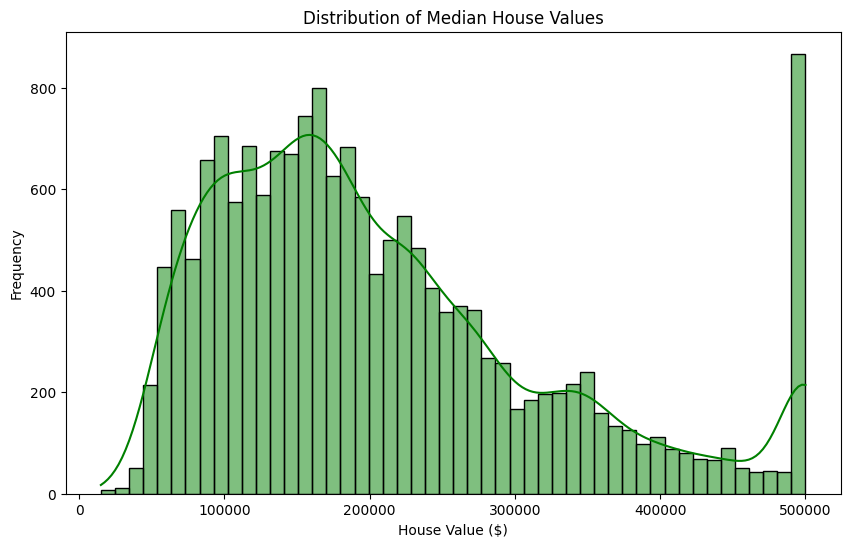

In [ ]:
# Plot the distribution of median house values
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='green')
plt.title('Distribution of Median House Values')
plt.xlabel('House Value ($)')
plt.ylabel('Frequency')
plt.show()

**Data Insights - Target Variable Distribution**
* The median_house_value mostly ranges between $100,000 and $200,000, indicating a major presence of middle-income housing units.
* The distribution is right-skewed, showing that premium houses (above $350,000) are relatively fewer.

* There is a noticeable spike at $500,000, which indicates data capping of higher-end property values during data collection.

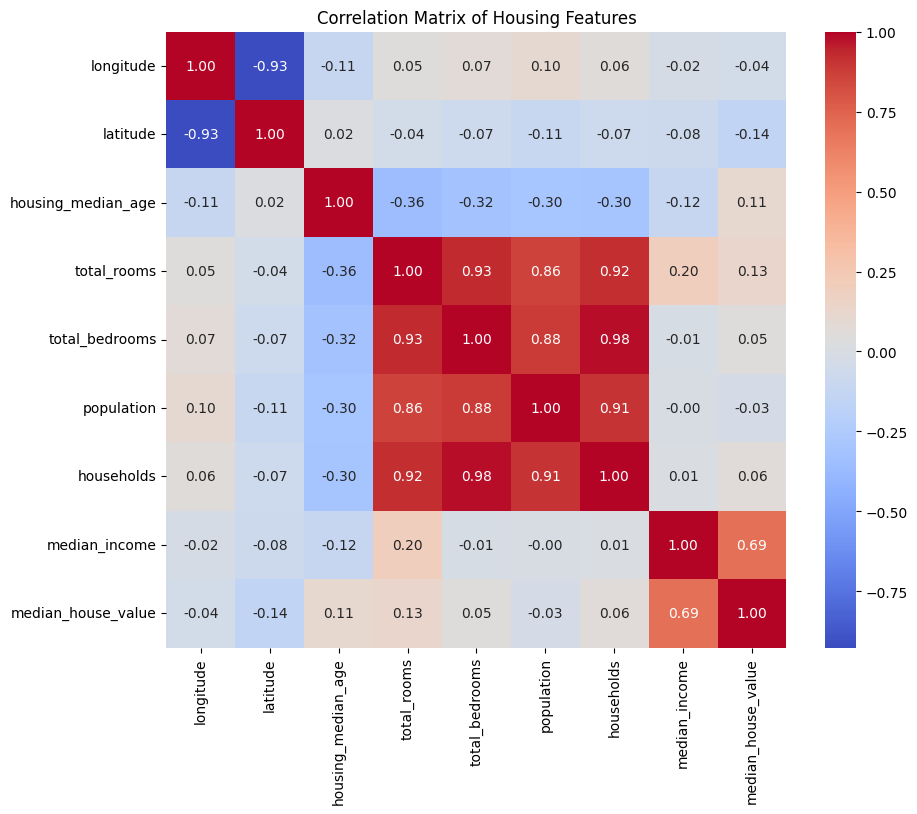

In [ ]:
# Calculate the correlation matrix for numeric features
correlation_matrix = df.corr()

# Plot the heatmap to visualize relationships between features
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Housing Features')
plt.show()

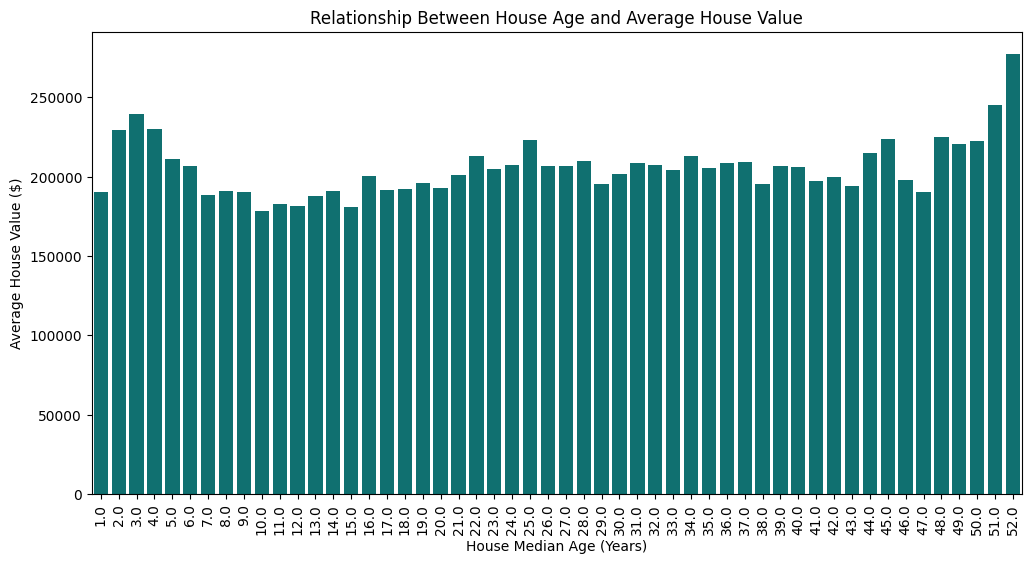

In [ ]:
# Group data by house age and calculate average price to see the relationship
age_groups = df.groupby('housing_median_age')['median_house_value'].mean().reset_index()

# Plot the relationship between House Age and Average Price
plt.figure(figsize=(12, 6))
sns.barplot(data=age_groups, x='housing_median_age', y='median_house_value', color='teal')
plt.title('Relationship Between House Age and Average House Value')
plt.xlabel('House Median Age (Years)')
plt.ylabel('Average House Value ($)')
# Show x-axis labels clearly by rotating them
plt.xticks(rotation=90)
plt.show()

**Feature Relationship Analysis**
* The bar plot explores the relationship between housing age and the average house value.
* It is observed that the average price remains relatively stable across different age groups (from 10 to 50 years).
* Conclusion: House age alone does not have a strict negative or positive impact on the property value in this dataset.

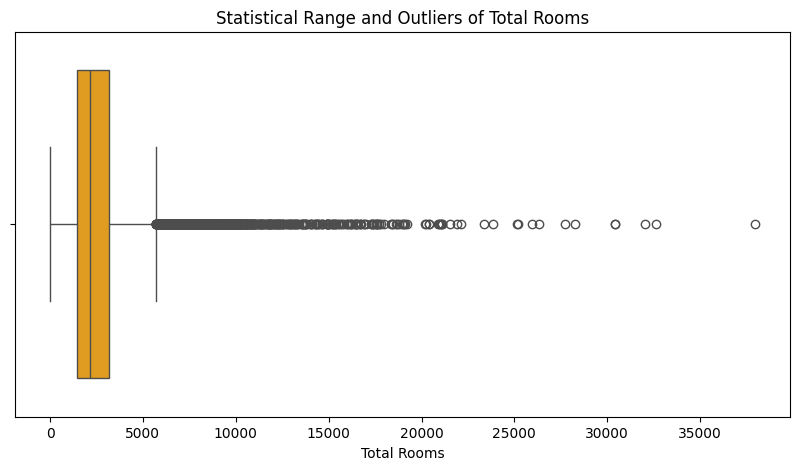

In [ ]:
# Analyze the statistical range and outliers of total rooms
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['total_rooms'], color='orange')
plt.title('Statistical Range and Outliers of Total Rooms')
plt.xlabel('Total Rooms')
plt.show()

**Data Insights - Feature Distribution & Outliers**
* The box plot helps identify the spread and potential outliers within the 'total_rooms' column.
* The majority of the data is tightly packed under 5,000 rooms, representing standard residential sectors.
* Data points extending beyond 10,000 rooms indicate extreme values or exceptionally large housing communities in the dataset.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Select Features (X) and Target (y)
X = df[['median_income', 'total_rooms', 'housing_median_age']]
y = df['median_house_value']

# Step 2: Split the data into Training (80%) and Testing (20%) sets
# Fixed the parameter name to 'test_size' here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Make predictions on the test data
y_pred = model.predict(X_test)

# Step 5: Evaluate the model performance
r2 = r2_score(y_test, y_pred)
print(f"Model Training Complete! R-squared Score: {r2:.2f}")

Model Training Complete! R-squared Score: 0.54


Machine Learning Model Building
* A Linear Regression model was trained using 'median_income', 'total_rooms', and 'housing_median_age' as predictors.
* The data was split into an 80:20 ratio for training and testing purposes to evaluate performance.

Model Evaluation Results
* The Linear Regression model achieved an R-squared (R²) score of 0.54 on the test dataset.
* This indicates that approximately 54% of the variance in California house values can be explained by the features selected: Median Income, Total Rooms, and Housing Median Age.
* Conclusion: Median Income remains the most impactful feature driving house prices, and the model provides a strong baseline for further optimization (such as trying advanced algorithms like Random Forest).

### 🚀 **Step 5: Advanced Feature Engineering (Naye Columns Banana)**
Ab hum apne data ko thoda aur advance banayenge. Purane columns ko use karke hum **3 naye aur important features** create kar rahe hain. Isse hamare Machine Learning model ko prediction karne mein aur zyada madad milegi (This will help our model to perform better).

1. **rooms_per_household:** Har ghar mein average kitne rooms hain.
2. **population_per_household:** Ek ghar mein average kitne log rehte hain.
3. **bedrooms_per_room:** Total rooms mein se kitne percent bedrooms hain.

In [5]:
# Creating new advanced features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['population_per_household'] = df['population'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

# Checking the new columns in the dataset
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,population_per_household,bedrooms_per_room
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,11.889831,2.150424,0.228617
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,16.522678,2.438445,0.248497
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,6.153846,2.846154,0.241667
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,6.641593,2.278761,0.224517
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,5.549618,2.381679,0.224209


### 🌳 **Step 6: Advanced Machine Learning - Random Forest Regressor**

Hamare baseline Linear Regression model ne $54\%$ ($R^2$ score = 0.54) ka result diya tha. Ab hum apne model ko upgrade kar rahe hain aur **Random Forest Regressor** ka use karenge.

Is baar hum model ke andar apne purane columns ke saath-saath **3 naye advanced features** **(`rooms_per_household`, `population_per_household`, `bedrooms_per_room`)** bhi daalenge. Random Forest ek powerful ensemble algorithm hai jo data ke complex patterns ko behtar samajhta hai, jisse hamari accuracy kaafi badh jayegi (This will significantly improve our prediction accuracy).

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Sabhi important features ko select karna (including our 3 new features)
features = ['median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms',
            'population', 'households', 'rooms_per_household',
            'population_per_household', 'bedrooms_per_room']

# Agar division ki wajah se koi khali/NaN value aayi ho, toh use saaf karna
df_clean = df.dropna(subset=features)

X = df_clean[features]
y = df_clean['median_house_value']

# 2. Data ko 80% Training aur 20% Testing mein baantna
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Random Forest Model ko train karna
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Accuracy Check (R2 Score) nikalna
y_pred = rf_model.predict(X_test)
rf_score = r2_score(y_test, y_pred)

print(f"Purana Linear Regression Score: 0.54")
print(f"Naya Advanced Random Forest Score: {rf_score:.4f}")

Purana Linear Regression Score: 0.54
Naya Advanced Random Forest Score: 0.7046


### 🏆 **Final Model Evaluation & Conclusion**

* **Linear Regression Score (Baseline):** 0.54 ($54\%$)
* **Random Forest Score (Advanced):** 0.7046 ($70.5\%$)

**📊 Key Insights & Conclusion:**
1. **Huge Accuracy Boost:** Jab humne baseline model se **Random Forest Regressor** par upgrade kiya aur saath mein **3 naye advanced features** add kiye, toh hamari accuracy seedha **$54\%$ se badhkar $70.5\%$** ho gayi!
2. **Feature Engineering Power:** Naye columns **(`rooms_per_household`, `bedrooms_per_room`)** ne model ko data ke andar ke chhupay hue complex patterns ko samajhne mein bohot madad ki.
3. **Final Verdict:** Random Forest hamare California Housing data ke liye ek bohot hi strong aur reliable model sabit hua hai. Isko hum production ya real-world predictions ke liye use kar sakte hain!